## Outliers in Data

#### Outliers Detection and Removal using Z-score Method [the data should be normally distributed & has a bell shaped curve]


*   First Check the Data is normally distributed or closed to normally distributed.
*   In a normal distribution, about 99.7% of all data points fall within 3 standard deviations of the mean.and 68% between Z-Score 1 , -1.
*   Then we define a range and check the data which are outside that range and this way we can find the z-score.

* Then we choose b/w the 2methods Trimming[Removing the outlier data row] & Cappping[Replace with the specific upper or lower threshold limits].

In [23]:
import pandas
df = pandas.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv')

df.sample(5)


,cgpa,placement_exam_marks,placed
249,7.46,52.0,0
907,7.03,44.0,1
922,7.68,23.0,1
295,6.02,64.0,0
396,7.28,10.0,1


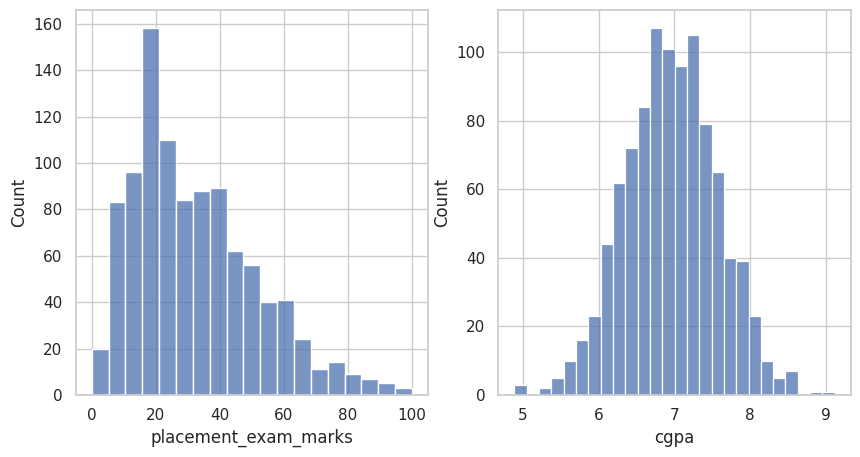

In [24]:
# Plot a histogram side by side of the df['placement_exam_marks'] and df['cgpa']
# in one frame
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['placement_exam_marks'], ax=ax[0])
sns.histplot(df['cgpa'], ax=ax[1])
plt.show()


In [25]:
#CGPA is Normally Distributed
print('Mean of placement_exam_marks is', df['placement_exam_marks'].mean())
print('Standard Deviation of placement_exam_marks is', df['placement_exam_marks'].std())
print('Mean of cgpa is', df['cgpa'].mean())
print('Standard Deviation of cgpa is', df['cgpa'].std())

Mean of placement_exam_marks is 32.225
Standard Deviation of placement_exam_marks is 19.13082233892108
Mean of cgpa is 6.96124
Standard Deviation of cgpa is 0.6158978751323894


In [26]:
#Now make a boundary of a from the standard deviation
upper_boundary = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_boundary = df['cgpa'].mean() - 3 * df['cgpa'].std()

#Now remove the following data which are outliers in the placement_exam_marks
df[(df['cgpa'] > upper_boundary) | (df['cgpa'] < lower_boundary)]


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


##### Approach 1 [ TRIMMING ]

In [27]:
#Trimming

new_df =  df[(df['cgpa'] < upper_boundary) & (df['cgpa'] > lower_boundary)]
new_df.shape

#G

(995, 3)

#####Approach 2 [ TRIMMING ]

In [28]:
#Calcualte the ZScore
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std() #ZScore Formuale

df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


##### Approach 3 [Capping]

In [29]:
import numpy as np

df_capped = df.copy()
df_capped['cgpa'] = np.where(
    df_capped['cgpa'] > upper_boundary, upper_boundary,
    np.where(
        df_capped['cgpa'] < lower_boundary, lower_boundary,
        df_capped['cgpa']
    )
)

print(df_capped.head())

   cgpa  placement_exam_marks  placed  cgpa_zscore
0  7.19                  26.0       1     0.371425
1  7.46                  38.0       1     0.809810
2  7.54                  40.0       1     0.939701
3  6.42                   8.0       1    -0.878782
4  7.23                  17.0       0     0.436371


### Outlier Detection using IQR [ works better on skwed data]

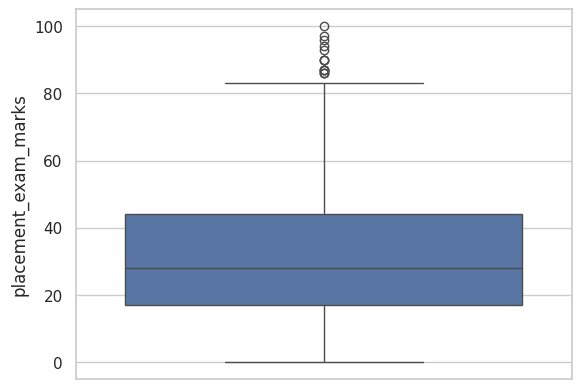

In [30]:
#Plot a boxplot on cgpa of df
sns.boxplot(df['placement_exam_marks'])
plt.show()
#

In [31]:
#Find the IQR of the placement_exam_marks coloumn in df
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)
iqr = q3 - q1
print(iqr)

# Find the upper and lower limits from the data
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
print(upper_limit, lower_limit)

27.0
84.5 -23.5


### Outliers Detection using the percentile Method

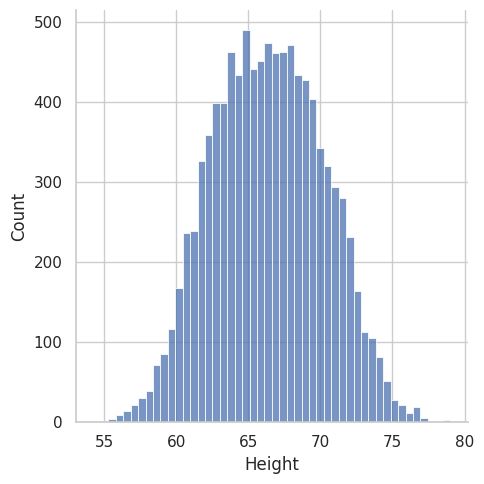

In [32]:
new_df = pandas.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day44-outlier-detection-using-percentiles/weight-height.csv')
new_df.head()
# PLOAT A DISPLOT OF HEIGHT USING SEABORN
sns.displot(new_df['Height'])
plt.show()

In [33]:
#It is a bell shaped Graph Normally distributed
new_df['Height'].describe()
#Describe a Upper and Lower Limit for the following data as 1 and 99%ile
upper_limit = new_df['Height'].quantile(0.99)
lower_limit = new_df['Height'].quantile(0.01)
print(upper_limit, lower_limit)

74.7857900583366 58.13441158671655


In [34]:
#Filter the Data using the Upper and Lower Limit
new_df = new_df[(new_df['Height'] <= upper_limit) & (new_df['Height'] >= lower_limit)]

#####  #Now the Outliers are removed after the Trimming of the Outliers

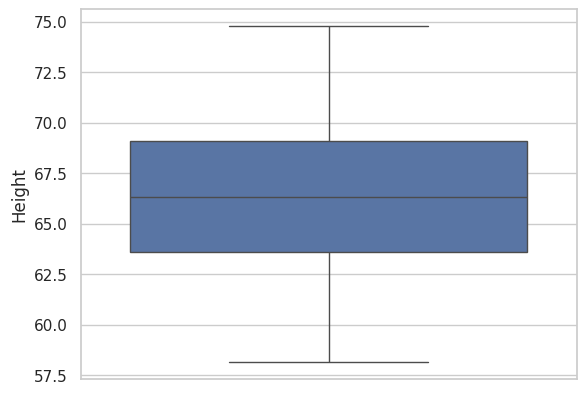

In [35]:
new_df.shape

#Plot a boxPlot on the height value of new_df
sns.boxplot(new_df['Height'])
plt.show()


##### Applying the Winsorzation as we are delaling with the Percentile Method

In [35]:
#Now Rather than trimming perform Capping
np.where(new_df['Height'] > upper_limit, upper_limit,
    np.where(
        new_df['Height'] < lower_limit, lower_limit,
        new_df['Height']
    )
)
